# Delivery Time Prediction

**Goal :** Regression model to predict `DeliveryTimeMinutes`. Functions are in `src/model_delivery.py`.

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import sys
import os
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
sys.path.append(os.path.abspath('../src'))
from model_delivery import (
    load_delivery_data, split_data, cross_validate_models, train_and_compare, tune_models,
    evaluate, get_feature_importance, save_outputs,
    NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET
)

## 1. Data

- Only `Delivered` and `Delivered Late` orders are used. Cancelled orders also have a delivery time in the data, but no delivery actually happened.
- 89 orders at exactly 180 min are dropped. These are outliers that were capped at 180 during cleaning, not real delivery times.
- `OrderStatus` is not used as a feature, since "Delivered Late" is only known after delivery.

| Feature | Source |
|---|---|
| `TrafficScore`, `RainImpact`, `PeakHour`, `WeekendOrder`, `OrderHour`, `DeliveryEfficiency` | `featured_orders` (04_Feature_Engineering) |
| `BasketSize` | total item quantity in the order (`order_items`) |
| `MaxPrepTime` | longest preparation time among the ordered items (`menu`) |
| `FoodCost` | `orders` |
| `VehicleType` | `delivery_partners` |

Distance is not included. Restaurant-to-customer distance can't be calculated because `customers.csv` have no coordinates, and `restaurants.csv` coordinates don't match their city.

In [7]:
df = load_delivery_data()
print("Orders:", df.shape)
df.head()

Orders: (13455, 12)


,OrderID,TrafficScore,RainImpact,PeakHour,WeekendOrder,OrderHour,DeliveryEfficiency,BasketSize,MaxPrepTime,FoodCost,VehicleType,DeliveryTimeMinutes
0,115395,1,0,0,1,7,1.0,3,26,277.0,Bike,49
1,112205,3,1,0,1,9,1.0,4,24,527.0,Bicycle,51
2,118972,2,0,0,1,10,1.0,8,37,486.0,Bike,55
3,113349,3,1,1,1,12,1.0,1,29,609.0,Bike,45
4,113866,3,0,1,1,12,1.0,4,20,529.0,Bicycle,37


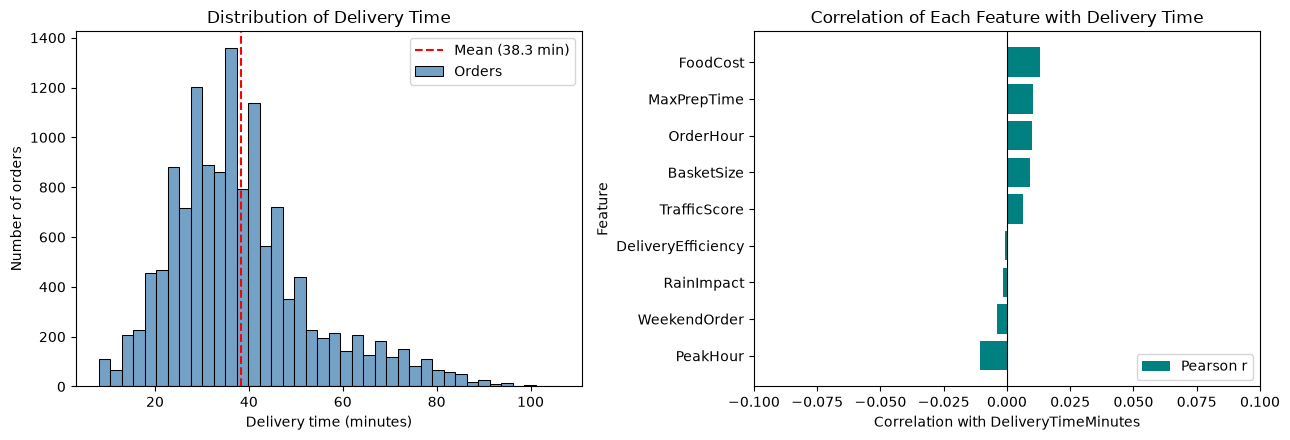

VehicleType
Bicycle    37.8
Bike       38.5
Car        38.0
Scooter    38.4
Name: DeliveryTimeMinutes, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df[TARGET], bins=40, color='steelblue', ax=axes[0], label='Orders')
axes[0].axvline(df[TARGET].mean(), color='red', linestyle='--', label=f"Mean ({df[TARGET].mean():.1f} min)")
axes[0].set_title('Distribution of Delivery Time')
axes[0].set_xlabel('Delivery time (minutes)')
axes[0].set_ylabel('Number of orders')
axes[0].legend()

corr = df[NUMERIC_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
axes[1].barh(corr.index, corr.values, color='teal', label='Pearson r')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlim(-0.1, 0.1)
axes[1].set_title('Correlation of Each Feature with Delivery Time')
axes[1].set_xlabel('Correlation with DeliveryTimeMinutes')
axes[1].set_ylabel('Feature')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print(df[CATEGORICAL_FEATURES + [TARGET]].groupby('VehicleType')[TARGET].mean().round(1))

**Observations**
- Delivery time averages 38.3 min and is right-skewed. Most orders take 20–50 min.
- No feature is correlated with delivery time: all correlations are between −0.011 and 0.013.
- Average time by vehicle type differs by less than a minute (37.8–38.5 min).

## 2. Train/Test Split and Cross-Validation

80/20 split. 5-fold CV is run on the training set only. `Baseline (mean)` always predicts the average delivery time of the training set, so any useful model has to beat it.

Preprocessing: `StandardScaler` for numeric features, `OneHotEncoder` for `VehicleType`.

In [9]:
X_train, X_test, y_train, y_test = split_data(df)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (10764, 10) | Test: (2691, 10)


In [10]:
cv_results = cross_validate_models(X_train, y_train)
cv_results

,CV RMSE,CV RMSE std,CV R2
Model,,,
Baseline (mean),15.322,0.226,-0.001
Linear Regression,15.329,0.224,-0.002
Decision Tree,15.806,0.462,-0.065
Random Forest,15.394,0.244,-0.010
Gradient Boosting,15.382,0.235,-0.009


## 3. Test Set Comparison

In [11]:
comparison, fitted_models = train_and_compare(X_train, X_test, y_train, y_test)
comparison

,MAE,MSE,RMSE,R2
Model,,,,
Baseline (mean),11.253,220.743,14.857,-0.000
Linear Regression,11.261,221.145,14.871,-0.002
Decision Tree,11.610,237.950,15.426,-0.078
Random Forest,11.322,222.742,14.925,-0.009
Gradient Boosting,11.305,222.387,14.913,-0.008


## 4. Hyperparameter Tuning

The two tree models with the lowest CV RMSE are tuned with `RandomizedSearchCV` (10 combinations, 3-fold CV, scored on RMSE). Linear Regression has no hyperparameters to tune.

In [12]:
tree_models = cv_results.loc[['Decision Tree', 'Random Forest', 'Gradient Boosting']]
to_tune = tree_models.sort_values('CV RMSE').index[:2].tolist()
print("Tuning:", to_tune)

tuned_models, best_params = tune_models(to_tune, X_train, y_train)
for name, params in best_params.items():
    print(f"{name}: {params}")

Tuning: ['Gradient Boosting', 'Random Forest']
Gradient Boosting: {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.01}
Random Forest: {'n_estimators': 300, 'min_samples_leaf': 20, 'max_depth': 5}


In [13]:
for name, pipe in tuned_models.items():
    comparison.loc[name] = pd.Series(evaluate(pipe, X_test, y_test)).round(3)
    fitted_models[name] = pipe

comparison.sort_values('RMSE')

,MAE,MSE,RMSE,R2
Model,,,,
Baseline (mean),11.253,220.743,14.857,-0.000
Gradient Boosting (tuned),11.252,220.763,14.858,-0.000
Linear Regression,11.261,221.145,14.871,-0.002
Random Forest (tuned),11.280,221.399,14.879,-0.003
Gradient Boosting,11.305,222.387,14.913,-0.008
Random Forest,11.322,222.742,14.925,-0.009
Decision Tree,11.610,237.950,15.426,-0.078


In [14]:
best_name = comparison.drop(index='Baseline (mean)')['RMSE'].idxmin()
best_model = fitted_models[best_name]
print("Best model (lowest test RMSE):", best_name)

Best model (lowest test RMSE): Gradient Boosting (tuned)


## 5. Evaluation of the Best Model

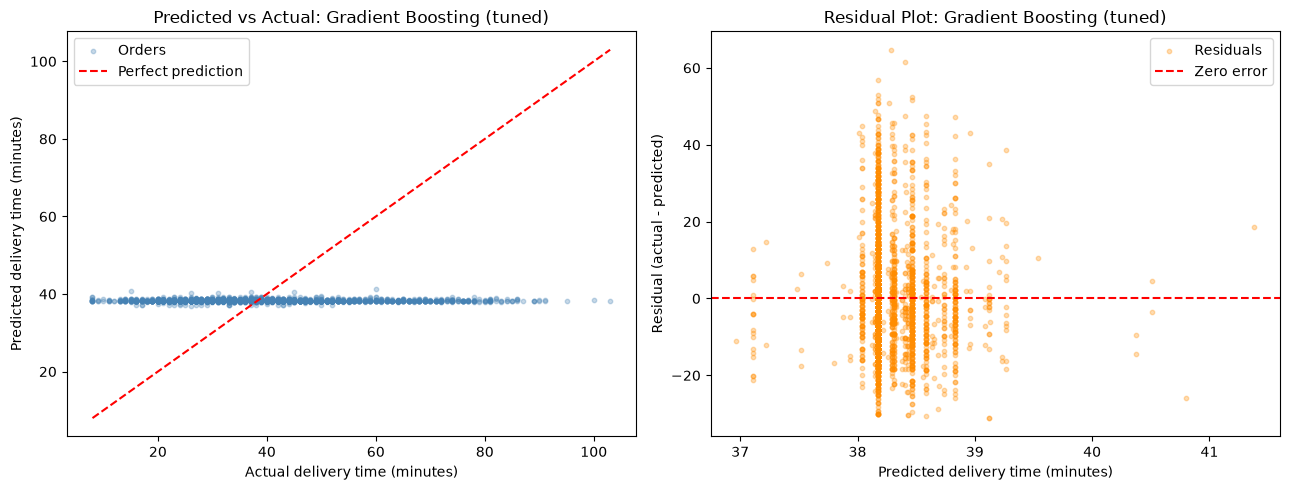

Predicted range: 37.0 to 41.4 min | Actual range: 8 to 103 min


In [15]:
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue', label='Orders')
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, color='red', linestyle='--', label='Perfect prediction')
axes[0].set_title(f'Predicted vs Actual: {best_name}')
axes[0].set_xlabel('Actual delivery time (minutes)')
axes[0].set_ylabel('Predicted delivery time (minutes)')
axes[0].legend()

axes[1].scatter(y_pred, residuals, alpha=0.3, s=10, color='darkorange', label='Residuals')
axes[1].axhline(0, color='red', linestyle='--', label='Zero error')
axes[1].set_title(f'Residual Plot: {best_name}')
axes[1].set_xlabel('Predicted delivery time (minutes)')
axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Predicted range: {y_pred.min():.1f} to {y_pred.max():.1f} min | Actual range: {y_test.min()} to {y_test.max()} min")

## 6. Feature Importance

Built-in feature importance of the best tuned tree model.

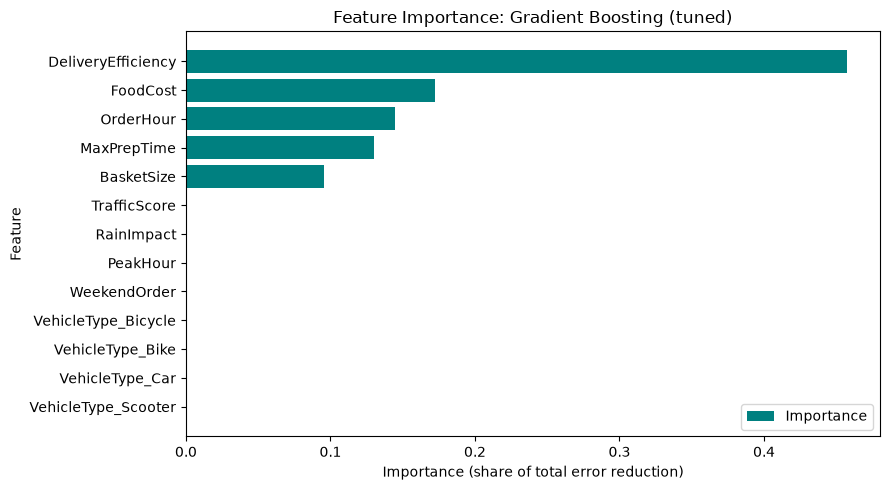

,Feature,Importance
0,DeliveryEfficiency,0.4574
1,FoodCost,0.1721
2,OrderHour,0.1445
3,MaxPrepTime,0.1304
4,BasketSize,0.0956
5,TrafficScore,0.0000
6,RainImpact,0.0000
7,PeakHour,0.0000
8,WeekendOrder,0.0000
9,VehicleType_Bicycle,0.0000


In [16]:
tuned_rmse = comparison.loc[list(tuned_models), 'RMSE']
best_tree = tuned_rmse.idxmin()
importance = get_feature_importance(fitted_models[best_tree])

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance['Feature'][::-1], importance['Importance'][::-1], color='teal', label='Importance')
ax.set_title(f'Feature Importance: {best_tree}')
ax.set_xlabel('Importance (share of total error reduction)')
ax.set_ylabel('Feature')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

importance.round(4)

**Observations**
- No model beats the baseline. In CV, every model has an RMSE of 15.3 min or higher (baseline 15.32) and an R² of 0 or slightly negative.
- Tuning picked the most restricted settings (e.g. Gradient Boosting with depth 2 and learning rate 0.01). This pushes the predictions toward the average. The tuned model ends up equal to the baseline on the test set (RMSE 14.86, R² 0.00).
- The predicted vs actual plot shows this: every prediction falls between 37 and 41 min, whatever the actual time (8–103 min).
- Feature importance puts `DeliveryEfficiency`, `FoodCost` and `OrderHour` on top. Because the model is no better than the mean, these importances come from noise and don't show real drivers of delay.

## 7. Save Outputs

In [17]:
predictions = pd.DataFrame({
    'OrderID': df.loc[X_test.index, 'OrderID'],
    'Actual': y_test,
    'Predicted': y_pred,
})
save_outputs(best_model, predictions, importance)

reloaded = joblib.load('../models/delivery_time_best_model.pkl')
print("Reloaded model gives same predictions:", np.allclose(reloaded.predict(X_test), y_pred))

Saved models/delivery_time_best_model.pkl, data/processed/delivery_predictions.csv and data/processed/delivery_feature_importance.csv
Reloaded model gives same predictions: True


## Summary

| PRD item | Status |
|---|---|
| LR, DT, RF, GB compared | Done |
| 80/20 split + 5-fold CV | Done |
| Tuning of the top 2 models | Done (RandomizedSearchCV on GB and RF) |
| Feature importance of the best tree model | Done |
| MAE, MSE, RMSE, R², residual and predicted-vs-actual plots | Done |
| R² ≥ 0.75, RMSE ≤ 6 min | Not met: best R² 0.00, RMSE 14.86 min |

Delivery time in this dataset doesn't depend on traffic, weather, time of day, basket size, preparation time or the delivery partner. So no model can predict it better than the average (38 min). Restaurant-to-customer distance, usually the strongest predictor, can't be calculated because customers have no coordinates.

Saved: `models/delivery_time_best_model.pkl`, plus `delivery_predictions.csv` and `delivery_feature_importance.csv` in `data/processed/` for the Power BI ML page.